# Surface Temperature Override Functionality

This notebook demonstrates the new surface temperature override capability in PyRadtran. You can now make the surface temperature modifiable, similar to albedo, for both thermal and solar simulations!

In [1]:
# Import PyRadtran components
from pyradtran.config import PathsConfig, SimulationDefaults, SimulationConfig, ExecutionConfig, OutputConfig, load_config
from pyradtran.core import Simulation, generate_input_content
from pyradtran.io import parse_uvspec_output
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
from dataclasses import asdict
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import os
import yaml
import pandas as pd

# Load the configuration from the YAML file
config_path = Path('../config/spectral_config.yaml')
import logging
# deactivate logging for pyradtran
logging.getLogger('pyradtran').setLevel(logging.CRITICAL)

N_timesteps = 24

ds = xr.Dataset(
    coords={
        'time' : pd.date_range('2025-04-04', periods=N_timesteps, freq='h'),
        'latitude' : ('time', [60.0] * N_timesteps),
        'longitude' : ('time', [20.0] * N_timesteps),
        'altitude' : ('altitude', [0.4]),
    }
)

dsera5 = xr.open_dataset('/projekt_agmwend/data_raw/COMPEX-EC/04_ERA5/ERA5_pressure_levels/20250404.nc')

# Debug: Let's examine the ERA5 dataset structure and the generated atmosphere file
print("=== ERA5 Dataset Information ===")
print(f"ERA5 dataset dimensions: {dsera5.dims}")
print(f"ERA5 dataset coordinates: {list(dsera5.coords)}")
print(f"ERA5 dataset variables: {list(dsera5.data_vars)}")

if 'valid_time' in dsera5.coords:
    print(f"Time range: {dsera5.valid_time.min().values} to {dsera5.valid_time.max().values}")
if 'pressure_level' in dsera5.coords:
    print(f"Pressure levels: {len(dsera5.pressure_level)} levels from {dsera5.pressure_level.min().values} to {dsera5.pressure_level.max().values} Pa")

# Check if ERA5 data covers our simulation time
sim_time = ds.time.values[0]
print(f"\nSimulation starts at: {sim_time}")

# Test ERA5 atmosphere file creation manually
from pyradtran.io import create_era5_atmosphere_file
from pathlib import Path
import tempfile

try:
    with tempfile.NamedTemporaryFile(mode='w', delete=False, suffix='.dat') as tmp:
        test_atm_file = create_era5_atmosphere_file(
            era5_ds=dsera5,
            latitude=78.0,
            longitude=0.0,
            time='2025-04-04T00:00:00',  # Use a time that exists in ERA5 data
            output_filepath=tmp.name
        )
        
        print(f"\n✓ Test atmosphere file created successfully: {test_atm_file}")
        
        # Read first few lines
        with open(test_atm_file, 'r') as f:
            lines = f.readlines()[:10]
            print("\nFirst 10 lines of test atmosphere file:")
            for i, line in enumerate(lines):
                print(f"  {i+1:2d}: {line.strip()}")
                
        # Clean up
        Path(test_atm_file).unlink()
        
except Exception as e:
    print(f"❌ Error creating test atmosphere file: {e}")
    import traceback
    traceback.print_exc()

/projekt_agmwend/home_rad/Joshua/micromamba/envs/mamba_josh/lib/python3.12/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gini' loading failed:
module 'numpy' has no attribute 'cumproduct'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


=== ERA5 Dataset Information ===
ERA5 dataset dimensions: FrozenMappingWarningOnValuesAccess({'valid_time': 24, 'pressure_level': 37, 'latitude': 54, 'longitude': 79})
ERA5 dataset coordinates: ['number', 'valid_time', 'pressure_level', 'latitude', 'longitude', 'expver']
ERA5 dataset variables: ['cc', 'z', 'o3', 'r', 'ciwc', 'clwc', 'q', 'crwc', 'cswc', 't', 'u', 'v', 'w']
Time range: 2025-04-04T00:00:00.000000000 to 2025-04-04T23:00:00.000000000
Pressure levels: 37 levels from 1.0 to 1000.0 Pa

Simulation starts at: 2025-04-04T00:00:00.000000000

✓ Test atmosphere file created successfully: /projekt_agmwend/home_rad/Joshua/tmp/tmpvt0kzayc.dat

First 10 lines of test atmosphere file:
   1: # ERA5 atmospheric profile, generated for libRadtran.
   2: # Location: lat=78.00, lon=0.00
   3: # Time: 2025-04-04 00:00:00
   4: # z(km) p(mb) T(K) air(cm-3) o3(cm-3) o2(cm-3) h2o(cm-3) co2(cm-3) no2(cm-3)
   5: 4.774100E+01 1.000000E+00 2.547681E+02 2.842966E+16 8.939174E+10 5.956014E+15 1.797673

In [5]:
# Import PyRadtran components
from pyradtran.config import PathsConfig, SimulationDefaults, SimulationConfig, ExecutionConfig, OutputConfig, load_config
from pyradtran.core import Simulation, generate_input_content
from pyradtran.io import parse_uvspec_output
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
from dataclasses import asdict
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import os
import yaml
import pandas as pd

# Load the configuration from the YAML file
config_path = Path('../config/spectral_config.yaml')
import logging
# deactivate logging for pyradtran
logging.getLogger('pyradtran').setLevel(logging.DEBUG)

N_timesteps = 24

ds = xr.Dataset(
    coords={
        'time' : pd.date_range('2025-04-04', periods=N_timesteps, freq='h'),
        'latitude' : ('time', [61.0] * N_timesteps),
        'longitude' : ('time', [22.0] * N_timesteps),
        'altitude' : ('altitude', [0.4]),
    }
)

dsera5 = xr.open_dataset('/projekt_agmwend/data_raw/COMPEX-EC/04_ERA5/ERA5_pressure_levels/20250404.nc')

In [8]:
config_path = Path('../config/thermal_config.yaml')

In [9]:
# Run a spectral simulation for a single point
ds = ds.pyradtran.run_uvspec(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
    era5_atmosphere=dsera5,  # Use the custom ERA5 atmosphere dataset
)

print("\nSimulation complete!")

2025-07-16 13:36:29,341 - pyradtran.config - INFO - Loading configuration from: ../config/thermal_config.yaml
2025-07-16 13:36:29,398 - pyradtran.config - INFO - Configuration loaded successfully.
2025-07-16 13:36:29,399 - pyradtran.interface - INFO - ERA5 atmosphere dataset validated with 37 pressure levels
2025-07-16 13:36:29,400 - pyradtran.interface - INFO - Overriding configuration altitude with 1 levels from dataset: [0.4]
2025-07-16 13:36:29,401 - pyradtran.interface - INFO - Auto-generating output path: work/xarray_example_20250716_133629.nc
2025-07-16 13:36:29,401 - pyradtran.interface - INFO - Creating ERA5 atmosphere files for simulation points...
2025-07-16 13:36:29,411 - pyradtran.io - INFO - 'co2' variable not found in dataset. Using constant 420 ppmv.
2025-07-16 13:36:29,412 - pyradtran.io - INFO - 'no2' variable not found in dataset. Using zero concentration.
2025-07-16 13:36:29,640 - pyradtran.io - INFO - Successfully created libRadtran atmosphere file at: work/era5_at


Simulation complete!


In [5]:
ds_track = xr.open_dataset('/projekt_agmwend/home_rad/Joshua/COMPEX-EC/compex_evi.nc')
ds_track

<xarray.Dataset> Size: 8MB
Dimensions:    (time: 117044)
Coordinates:
  * time       (time) datetime64[ns] 936kB 2025-04-04T10:39:47 ... 2025-04-15...
Data variables:
    pitch      (time) float64 936kB ...
    roll       (time) float64 936kB ...
    heading    (time) float64 936kB ...
    altitude   (time) float64 936kB ...
    gs         (time) float64 936kB ...
    latitude   (time) float64 936kB ...
    longitude  (time) float64 936kB ...
    vs         (time) float64 936kB ...
Attributes: (12/15)
    title:          P5 position and attitude data
    description:    1 Hz subset based on GPS1 and INS data processed by AWI e...
    instruments:    GPS1 and INS
    version:        1.1
    institution:    Alfred-Wegener-Institut Helmholtz-Zentrum für Polar- und ...
    author:         Dr. Mario Mech
    ...             ...
    featureType:    trajectory
    mission:        COMPEX-EC
    platform:       P5
    flight_number:  RF01
    history:        acquired by P5 during COMPEX-EC campaign, quality checked...
    created:        2025-04-04

In [6]:
ds_to_simulate = ds_track.sel(time='2025-04-04').resample(time='180S').mean(dim='time')

config_path_400_3200 = Path('../config/spectral_config_400_3200.yaml')
# show the progress of the simulation
print("Running spectral simulation with 400-3200 nm range...")

logging.getLogger('pyradtran').setLevel(logging.DEBUG)  # Ensure logging is set to critical to avoid clutter
ds_sim = ds_to_simulate.pyradtran.run_uvspec(
    config_path=config_path_400_3200,
    return_dataset=True,
    save_to_file=True,
    era5_atmosphere=dsera5,  # Use the custom ERA5 atmosphere dataset
)


/projekt_agmwend/home_rad/Joshua/micromamba/envs/mamba_josh/lib/python3.12/site-packages/xarray/groupers.py:513: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  self.index_grouper = pd.Grouper(
2025-07-15 01:08:13,773 - flox - INFO - Entering _validate_reindex: reindex is None
2025-07-15 01:08:13,774 - flox - INFO - Leaving _validate_reindex: method = None, returning None
2025-07-15 01:08:13,774 - flox - INFO - _choose_engine: Choosing 'flox'
2025-07-15 01:08:13,776 - flox - INFO - Entering _validate_reindex: reindex is None
2025-07-15 01:08:13,777 - flox - INFO - Leaving _validate_reindex: method = None, returning None
2025-07-15 01:08:13,778 - flox - INFO - _choose_engine: Choosing 'flox'
2025-07-15 01:08:13,779 - flox - INFO - Entering _validate_reindex: reindex is None
2025-07-15 01:08:13,780 - flox - INFO - Leaving _validate_reindex: method = None, returning None
2025-07-15 01:08:13,780 - flox - INFO - _choose_engine: Choosing 'f

Running spectral simulation with 400-3200 nm range...


2025-07-15 01:08:14,000 - pyradtran.io - INFO - 'no2' variable not found in dataset. Using zero concentration.
2025-07-15 01:08:14,032 - pyradtran.io - INFO - Successfully created libRadtran atmosphere file at: work/era5_atmospheres/era5_atm_20250404_110600_67.94_20.44.dat
2025-07-15 01:08:14,035 - pyradtran.interface - DEBUG - Created ERA5 atmosphere file for 20250404_110600_67.94_20.44: work/era5_atmospheres/era5_atm_20250404_110600_67.94_20.44.dat
2025-07-15 01:08:14,044 - pyradtran.io - INFO - 'co2' variable not found in dataset. Using constant 420 ppmv.
2025-07-15 01:08:14,045 - pyradtran.io - INFO - 'no2' variable not found in dataset. Using zero concentration.
2025-07-15 01:08:14,050 - pyradtran.io - INFO - Successfully created libRadtran atmosphere file at: work/era5_atmospheres/era5_atm_20250404_110900_68.03_20.51.dat
2025-07-15 01:08:14,051 - pyradtran.interface - DEBUG - Created ERA5 atmosphere file for 20250404_110900_68.03_20.51: work/era5_atmospheres/era5_atm_20250404_110

In [7]:
ds_sim_integrated = ds_sim.integrate('wavelength')

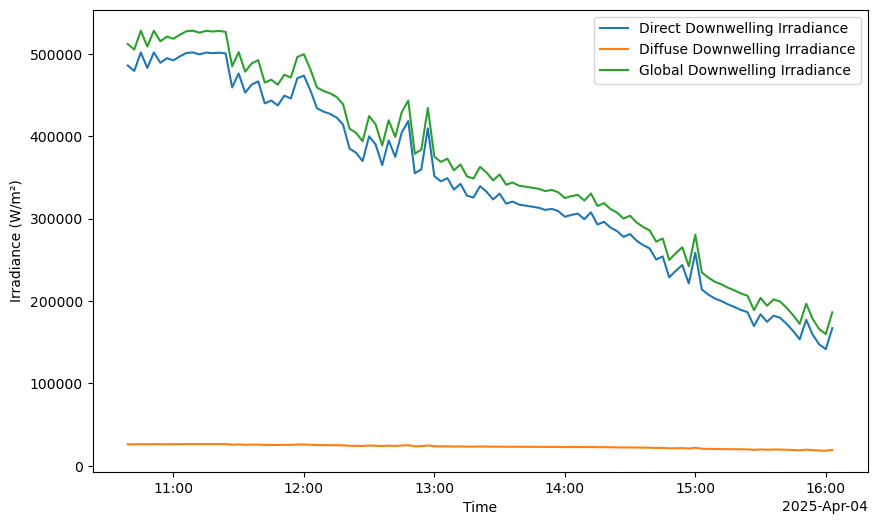

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

ds_sim_integrated['edir'].plot(ax=ax, label='Direct Downwelling Irradiance')
ds_sim_integrated['edn'].plot(ax=ax, label='Diffuse Downwelling Irradiance')
ds_sim_integrated['eglo'].plot(ax=ax, label='Global Downwelling Irradiance')
ax.set_xlabel('Time')
ax.set_ylabel('Irradiance (W/m²)')
ax.legend()


In [9]:
ds_measure = xr.open_dataset('/projekt_agmwend/home_rad/Joshua/COMPEX-EC/data/bbr_processed_test_level_v0.nc')

In [10]:
mean_alt = ds_track['altitude'].sel(time=slice('2025-04-04T11:35', '2025-04-04T15:35')).mean()
std_alt = ds_track['altitude'].sel(time=slice('2025-04-04T11:35', '2025-04-04T15:35')).std()
print(f"Mean altitude: {mean_alt.values} m")
print(f"Standard deviation of altitude: {std_alt.values} m")



Mean altitude: 3738.902756445792 m
Standard deviation of altitude: 17.00392617270128 m


<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
/projekt_agmwend/home_rad/Joshua/tmp/ipykernel_3726964/1890333130.py:20: SyntaxWarning: invalid escape sequence '\m'
  ax.set_zlabel('$F_\mathrm{dir}^\downarrow$ ($\mathrm{W m^{-2}}$)')


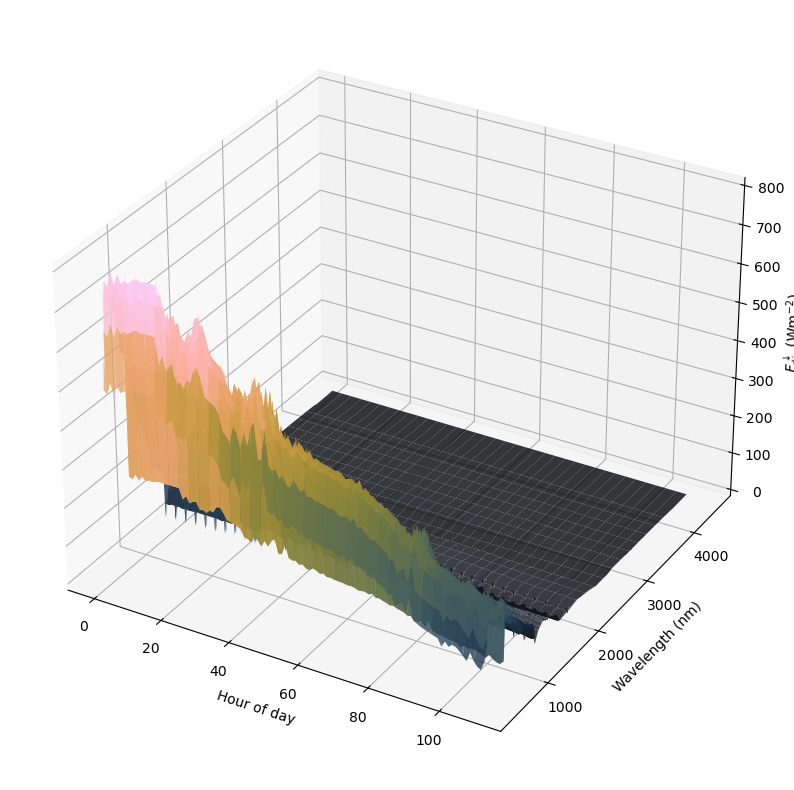

In [11]:
# Plot the results
from cmcrameri import cm

# make a 3d plot with time on the x-axis, wavelength on the y-axis, and irradiance on the z-axis
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.set_prop_cycle(
    color=cm.batlowK(np.linspace(0, 1, len(ds_sim['wavelength'].values))),
)

x = np.arange(len(ds_sim['time'].values))
y = ds_sim['wavelength'].values
z = ds_sim['edir'].values.T
X, Y = np.meshgrid(x, y)

ax.plot_surface(X, Y, z, cmap=cm.batlowK, edgecolor='none', alpha=0.8)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Wavelength (nm)')
ax.set_zlabel('$F_\mathrm{dir}^\downarrow$ ($\mathrm{W m^{-2}}$)')

plt.tight_layout()


In [12]:
ds_sim_integrated['F_dwn_sol'] = ds_sim_integrated['edir'] + ds_sim_integrated['edn']
ds_sim_integrated['F_dwn_sol_dif'] = ds_sim_integrated['edn']

In [36]:
ds_measure_interp = ds_measure.sel(time='2025-04-04').resample(time='180S').mean(dim='time').interp_like(ds_sim_integrated)
ds_measure_interp_std = ds_measure.sel(time='2025-04-04').resample(time='180S').std(dim='time').interp_like(ds_sim_integrated)


/projekt_agmwend/home_rad/Joshua/micromamba/envs/mamba_josh/lib/python3.12/site-packages/xarray/groupers.py:513: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  self.index_grouper = pd.Grouper(
2025-07-15 01:19:08,077 - flox - INFO - Entering _validate_reindex: reindex is None
2025-07-15 01:19:08,078 - flox - INFO - Leaving _validate_reindex: method = None, returning None
2025-07-15 01:19:08,080 - flox - INFO - _choose_engine: Choosing 'flox'
2025-07-15 01:19:08,088 - flox - INFO - Entering _validate_reindex: reindex is None
2025-07-15 01:19:08,089 - flox - INFO - Leaving _validate_reindex: method = None, returning None
2025-07-15 01:19:08,091 - flox - INFO - _choose_engine: Choosing 'flox'
2025-07-15 01:19:08,099 - flox - INFO - Entering _validate_reindex: reindex is None
2025-07-15 01:19:08,099 - flox - INFO - Leaving _validate_reindex: method = None, returning None
2025-07-15 01:19:08,102 - flox - INFO - _choose_engine: Choosing 'f

2025-07-15 01:19:08,131 - flox - INFO - _choose_engine: Choosing 'flox'
2025-07-15 01:19:08,138 - flox - INFO - Entering _validate_reindex: reindex is None
2025-07-15 01:19:08,139 - flox - INFO - Leaving _validate_reindex: method = None, returning None
2025-07-15 01:19:08,141 - flox - INFO - _choose_engine: Choosing 'flox'
2025-07-15 01:19:08,148 - flox - INFO - Entering _validate_reindex: reindex is None
2025-07-15 01:19:08,149 - flox - INFO - Leaving _validate_reindex: method = None, returning None
2025-07-15 01:19:08,151 - flox - INFO - _choose_engine: Choosing 'flox'
2025-07-15 01:19:08,158 - flox - INFO - Entering _validate_reindex: reindex is None
2025-07-15 01:19:08,159 - flox - INFO - Leaving _validate_reindex: method = None, returning None
2025-07-15 01:19:08,160 - flox - INFO - _choose_engine: Choosing 'flox'
2025-07-15 01:19:08,165 - flox - INFO - Entering _validate_reindex: reindex is None
2025-07-15 01:19:08,166 - flox - INFO - Leaving _validate_reindex: method = None, ret

In [41]:
ds_sim_integrated

<xarray.Dataset> Size: 11kB
Dimensions:        (time: 110)
Coordinates:
  * time           (time) datetime64[ns] 880B 2025-04-04T10:39:00 ... 2025-04...
Data variables:
    latitude       (time) float64 880B 67.82 67.82 67.82 ... 67.8 67.82 nan
    longitude      (time) float64 880B 20.33 20.33 20.33 ... 20.3 20.33 nan
    sza            (time) float64 880B 2.575e+05 2.59e+05 ... 3.261e+05 nan
    edir           (time) float64 880B 4.86e+05 4.794e+05 ... 1.671e+05 nan
    eglo           (time) float64 880B 5.121e+05 5.054e+05 ... 1.863e+05 nan
    edn            (time) float64 880B 2.61e+04 2.599e+04 ... 1.928e+04 nan
    eup            (time) float64 880B 1.43e+05 1.413e+05 ... 5.378e+04 nan
    enet           (time) float64 880B 3.692e+05 3.641e+05 ... 1.326e+05 nan
    albedo         (time) float64 880B nan nan nan nan nan ... nan nan nan nan
    F_dwn_sol      (time) float64 880B 5.121e+05 5.054e+05 ... 1.863e+05 nan
    F_dwn_sol_dif  (time) float64 880B 2.61e+04 2.599e+04 ... 1.928e+04 nan
Attributes:
    generated_by:      pyradtran
    wavelength_range:  400.0 to 4500.0 nm

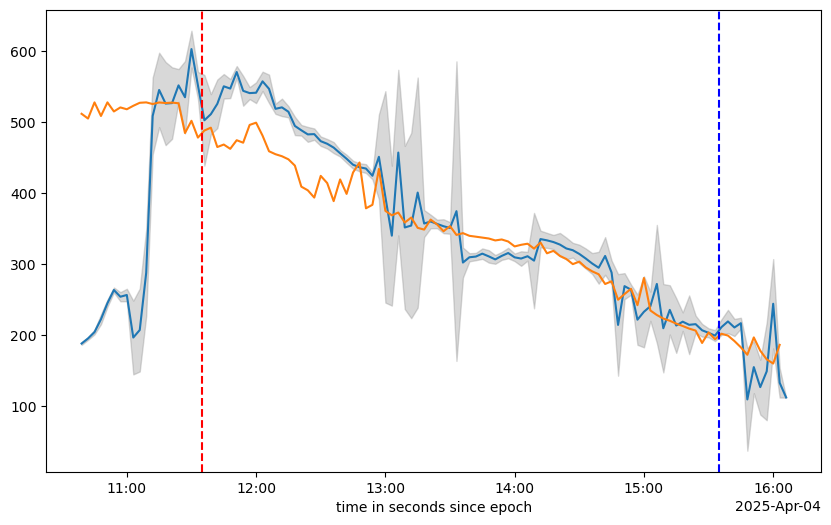

In [46]:
fig, ax = plt.subplots(figsize=(10, 6))

ds_measure_interp.F_dnw_sol.plot(ax=ax, label='Measured Downwelling Solar Irradiance')
# plot hthe std as a shaded area
ax.fill_between(
    ds_measure_interp['time'].values,
    ds_measure_interp.F_dnw_sol - ds_measure_interp_std.F_dnw_sol,
    ds_measure_interp.F_dnw_sol + ds_measure_interp_std.F_dnw_sol,
    color='gray', alpha=0.3, label='Measurement Std Dev'
)

((ds_sim_integrated['edir'] + ds_sim_integrated['edn']) / 1000).plot(ax=ax, label='Simulated Downwelling Solar Irradiance')

selected_slice = slice('2025-04-04T11:35', '2025-04-04T15:35')
## plot a vertical line at the slice start and end time

start_time = pd.to_datetime(selected_slice.start)
end_time = pd.to_datetime(selected_slice.stop)
ax.axvline(x=start_time, color='red', linestyle='--', label='Slice Start')
ax.axvline(x=end_time, color='blue', linestyle='--', label='Slice End')


In [47]:
ds_sim_sel = ds_sim_integrated.sel(time=selected_slice)
ds_measure_interp_sel = ds_measure_interp.sel(time=selected_slice)

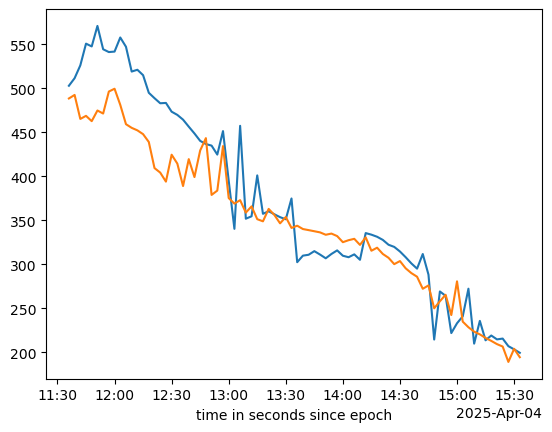

In [49]:
ds_measure_interp_sel.F_dnw_sol.plot()
((ds_sim_sel['edir'] + ds_sim_sel['edn']) / 1000).plot(label='Simulated Downwelling Solar Irradiance')


In [50]:
ds_measure_interp

<xarray.Dataset> Size: 12kB
Dimensions:    (time: 110)
Coordinates:
  * time       (time) datetime64[ns] 880B 2025-04-04T10:39:00 ... 2025-04-04T...
Data variables: (12/13)
    latitude   (time) float64 880B 67.82 67.82 67.82 67.82 ... 67.82 67.85 nan
    longitude  (time) float64 880B 20.33 20.33 20.33 20.33 ... 20.27 20.3 nan
    pitch      (time) float64 880B 10.23 10.22 10.28 10.39 ... 3.325 10.92 nan
    roll       (time) float64 880B 0.9545 0.9651 0.9524 ... -0.282 1.063 nan
    heading    (time) float64 880B 0.0 113.0 122.8 122.8 ... 29.57 -82.16 nan
    F_dnw_sol  (time) float64 880B 188.2 195.4 204.3 222.4 ... 244.3 132.9 112.2
    ...         ...
    F_dnw_ter  (time) float64 880B 287.2 287.6 289.2 287.8 ... 251.1 271.4 273.7
    F_upw_ter  (time) float64 880B 315.6 315.0 315.0 315.1 ... 295.6 311.5 309.6
    SOD        (time) float64 880B 3.845e+04 3.861e+04 ... 5.787e+04 5.796e+04
    t_kt19     (time) float64 880B 2.399 2.282 2.264 ... -11.27 -10.46 -10.13
    sza        (time) float64 880B 65.25 65.12 64.96 64.81 ... 70.25 70.48 70.6
    saa        (time) float64 880B 146.5 147.2 148.0 148.8 ... 233.9 234.7 235.0

Slope: 0.7439382946531468, Intercept: 74.33349860340542, R²: 0.9232114412766675


Text(0.5, 1.0, 'Comparison of Simulated and Measured Downwelling Solar Irradiance')

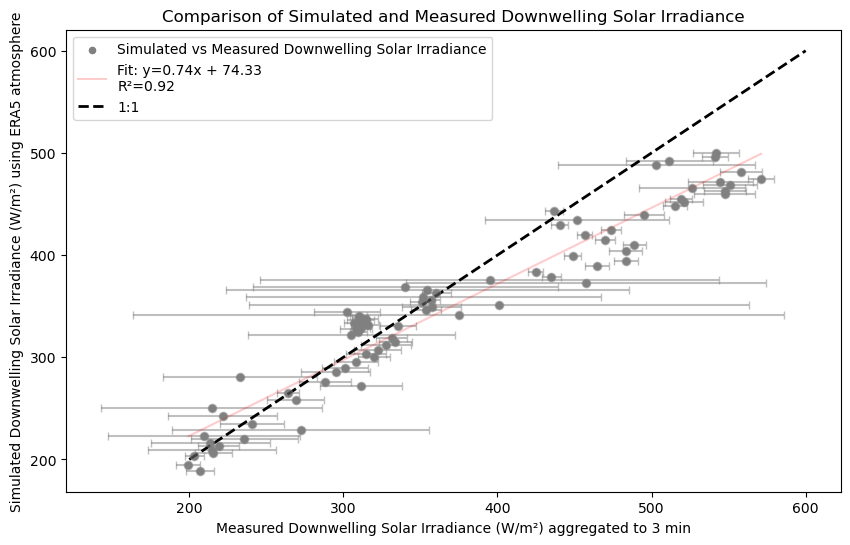

In [64]:
Y = (ds_sim_sel.eglo / 1000).values
X = ds_measure_interp_sel.F_dnw_sol.values
X_err = ds_measure_interp_std.sel(time=selected_slice).F_dnw_sol.values
nan_mask = ~np.isnan(X) & ~np.isnan(Y)
X = X[nan_mask]
Y = Y[nan_mask]
X_err = X_err[nan_mask]

plt.figure(figsize=(10, 6))
plt.scatter(X, Y, c='gray', label='Simulated vs Measured Downwelling Solar Irradiance', s=20)
plt.errorbar(X, Y, xerr=X_err, fmt='o', color='gray', alpha=0.5, capsize=3)


from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(X, Y)
print(f"Slope: {slope}, Intercept: {intercept}, R²: {r_value**2}")
x_fit = np.linspace(X.min(), X.max(), 100)
y_fit = slope * x_fit + intercept
plt.plot(x_fit, y_fit, color='red', label=f'Fit: y={slope:.2f}x + {intercept:.2f}\nR²={r_value**2:.2f}', alpha=0.2)
plt.plot([200, 600], [200, 600], lw=2, color='black', linestyle='--', label='1:1')
plt.legend()

plt.xlabel('Measured Downwelling Solar Irradiance (W/m²) aggregated to 3 min')
plt.ylabel('Simulated Downwelling Solar Irradiance (W/m²) using ERA5 atmosphere')
plt.title('Comparison of Simulated and Measured Downwelling Solar Irradiance')